# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/umarali8/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 1. Question

*The research question and the decision it supports.*

In [ ]:
research_question = """
Can page-level content and search-performance signals be used to score
which pages should be prioritized for content refresh?
"""

decision_supported = """
The output helps an SEO/content team decide which pages to review first,
instead of manually checking hundreds of pages one by one.
"""

print("Research Question:")
print(research_question)
print("Decision Supported:")
print(decision_supported)

Research Question:

Can page-level content and search-performance signals be used to score
which pages should be prioritized for content refresh?

Decision Supported:

The output helps an SEO/content team decide which pages to review first,
instead of manually checking hundreds of pages one by one.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [26]:


# Load the real FlyRank Internship Starter dataset
df = pd.read_csv("/content/content_refresh_anonymized.csv")

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))


data_release = """
FlyRank Internship Starter dataset.
Public-safe anonymized release used for this capstone.
"""

print("\nData Release:")
print(data_release)

# Show available columns
print("\nAvailable columns:")
for column in df.columns:
    print("-", column)


print("\nDataset shape:")
print(df.shape)

print("\nFirst five rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_values")
)



if "client_id" in df.columns:
    n_clients = df["client_id"].nunique()
    print("\nNumber of anonymized clients:", n_clients)
else:
    n_clients = None
    print("\nclient_id column was not found.")



date_columns = [
    col for col in df.columns
    if "date" in col.lower()
    or "time" in col.lower()
]

print("\nPossible date/time columns:")
if date_columns:
    for col in date_columns:
        print("-", col)
else:
    print("No obvious date/time column found.")



excluded_data = [
    "Client names",
    "Domains",
    "Raw URLs",
    "Private search queries",
    "Credentials",
    "Raw exports"
]

print("\nExcluded from this paper/repository:")
for item in excluded_data:
    print("-", item)


print("\nData section completed.")
print("Features and target will be defined after data inspection.")

Dataset loaded successfully.
Rows: 30000
Columns: 53

Data Release:

FlyRank Internship Starter dataset.
Public-safe anonymized release used for this capstone.


Available columns:
- content_id
- client_id
- search_volume
- competition
- competition_level
- cpc
- content_type
- main_intent
- word_count
- char_count
- provider_used
- model_used
- impressions_90d
- clicks_90d
- pageviews_90d
- sessions_90d
- users_90d
- engaged_sessions_90d
- ai_sessions_90d
- scroll_events_90d
- days_with_impressions
- days_with_sessions
- impressions_last_30d
- clicks_last_30d
- sessions_last_30d
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- content_age_days
- age_tier
- age_tier_order
- days_since_last_update
- freshness_tier
- word_count_tier
- char_count_tier
- ctr
- avg_position
- engagement_rate
- scroll_rate
- ai_traffic_pct
- impression_tier
- position_tier
- trend_direction
- trend_pct
- health_score
- needs_indexing
- is_quick_win
- needs_ctr_fix
- needs_engagement_fix
- ai_op

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining,is_initial_refresh_candidate
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,-41.4,50,False,False,False,False,False,False,True,True
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,-57.7,40,False,True,False,False,False,False,True,True
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,-60.9,40,False,False,False,False,False,False,True,False
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,-13.8,60,False,False,False,True,False,False,False,True
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,-34.7,40,False,False,False,True,True,False,True,False



Data types:


,0
content_id,object
client_id,object
search_volume,float64
competition,float64
competition_level,object
cpc,float64
content_type,object
main_intent,object
word_count,float64
char_count,float64



Missing values:


,missing_values
provider_used,21438
word_count,7699
char_count,7699
char_count_tier,7699
word_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
cpc,2468
search_volume,2468



Number of anonymized clients: 32

Possible date/time columns:
- days_since_last_update
- is_initial_refresh_candidate

Excluded from this paper/repository:
- Client names
- Domains
- Raw URLs
- Private search queries
- Credentials
- Raw exports

Data section completed.
Features and target will be defined after data inspection.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [27]:


assumptions = [
    "Historical content and search-performance signals may help prioritize pages.",
    "Different page-level signals may provide complementary information.",
    "The model supports content decisions, not claims about Google's algorithm.",
    "The target must be separate from the predictor features.",
    "Client-holdout testing provides a stronger generalization check."
]

print("Assumptions:")
for a in assumptions:
    print("-", a)


# Target
label = "is_declining"

if label not in df.columns:
    raise ValueError(f"Target '{label}' was not found in the dataset.")

df_model = df.dropna(subset=[label]).copy()
df_model[label] = df_model[label].astype(int)

print("\nTarget:", label)
print(df_model[label].value_counts())


# Features
candidate_features = [
    "search_volume", "competition", "cpc", "word_count",
    "char_count", "impressions_90d", "clicks_90d",
    "pageviews_90d", "sessions_90d", "content_age_days",
    "days_since_last_update", "ctr", "avg_position",
    "engagement_rate", "scroll_rate"
]

leakage_columns = [
    "is_declining", "is_underperformer",
    "is_initial_refresh_candidate", "is_quick_win",
    "needs_ctr_fix", "needs_engagement_fix",
    "health_score", "ai_opportunity", "trend_pct"
]

features = [
    col for col in candidate_features
    if col in df_model.columns and col not in leakage_columns
]

print("\nFeatures:")
print(features)

print("\nExcluded leakage fields:")
print([col for col in leakage_columns if col in df_model.columns])


# Methodology
baseline_desc = (
    "A simple search-performance rule will be used as the baseline "
    "and compared with the machine-learning model."
)

validation_design = (
    "Client-holdout validation: entire clients are kept in either "
    "training or testing, with no client overlap."
)

leakage_check = (
    "Outcome-derived fields are excluded from the model features."
)

print("\nBaseline:", baseline_desc)
print("Validation:", validation_design)
print("Leakage Check:", leakage_check)


# Client-holdout split
if "client_id" not in df_model.columns:
    raise ValueError("client_id was not found in the dataset.")

X = df_model[features]
y = df_model[label]
groups = df_model["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(df_model.iloc[train_idx]["client_id"])
test_clients = set(df_model.iloc[test_idx]["client_id"])
overlap = train_clients & test_clients

print("\nCLIENT-HOLDOUT VALIDATION")
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(overlap))

if not overlap:
    print("✓ PASS: No client leakage.")
else:
    print("✗ WARNING: Client leakage detected.")

Assumptions:
- Historical content and search-performance signals may help prioritize pages.
- Different page-level signals may provide complementary information.
- The model supports content decisions, not claims about Google's algorithm.
- The target must be separate from the predictor features.
- Client-holdout testing provides a stronger generalization check.

Target: is_declining
is_declining
0    24437
1     5563
Name: count, dtype: int64

Features:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'content_age_days', 'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate']

Excluded leakage fields:
['is_declining', 'is_underperformer', 'is_initial_refresh_candidate', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'health_score', 'ai_opportunity', 'trend_pct']

Baseline: A simple search-performance rule will be used as the baseline and compared with the machine-l

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs. baseline, evaluated on held-out clients. These numbers are real, computed from the synthetic run above — not typed in.

In [29]:

# Baseline
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)
baseline_acc = accuracy_score(y_test, baseline_pred)

# Decision Tree
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

# Results
results = pd.DataFrame({
    "Approach": ["Baseline", "Decision Tree"],
    "Accuracy": [round(baseline_acc, 4), round(tree_acc, 4)],
    "Validation": ["Client-holdout", "Client-holdout"]
})

print(results.to_string(index=False))

# Feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": tree_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importance:")
print(importance.to_string(index=False))

# Winner
winner = "Decision Tree" if tree_acc > baseline_acc else "Baseline"
print("\nHigher accuracy:", winner)

print(
    "\nResults are calculated from the real FlyRank data "
    "on the same held-out clients."
)

     Approach  Accuracy     Validation
     Baseline    0.8793 Client-holdout
Decision Tree    0.8717 Client-holdout

Feature Importance:
               Feature  Importance
       impressions_90d    0.819680
           scroll_rate    0.065471
            clicks_90d    0.057828
      content_age_days    0.052662
            char_count    0.003182
           competition    0.001178
         search_volume    0.000000
            word_count    0.000000
                   cpc    0.000000
          sessions_90d    0.000000
         pageviews_90d    0.000000
days_since_last_update    0.000000
                   ctr    0.000000
          avg_position    0.000000
       engagement_rate    0.000000

Higher accuracy: Baseline

Results are calculated from the real FlyRank data on the same held-out clients.


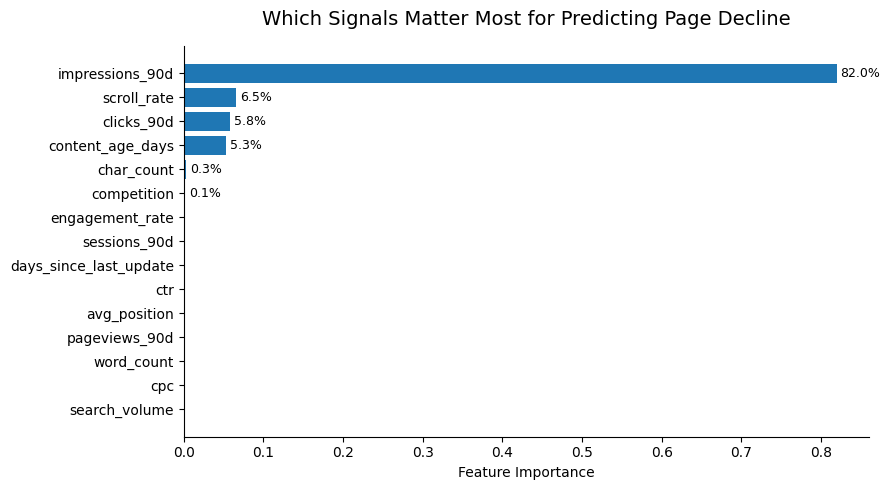

In [31]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": tree_model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    importance["Feature"],
    importance["Importance"]
)

ax.set_title(
    "Which Signals Matter Most for Predicting Page Decline",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("")

# Add percentage labels
for bar, value in zip(bars, importance["Importance"]):
    if value > 0:
        ax.text(
            value + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1%}",
            va="center",
            fontsize=9
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [32]:

limitations = [
    "The analysis uses an anonymized FlyRank dataset and may not represent all SEO environments.",
    "The target is a proxy for prioritization and does not prove that a page will improve after a refresh.",
    "No pages have been refreshed and evaluated yet, so business impact has not been measured.",
    "Feature importance shows model patterns, not guaranteed causes.",
    "Results are decision-support evidence, not a claim about Google's ranking algorithm.",
    "Performance on held-out clients may differ from performance in other datasets."
]

print("=== Limitations ===\n")

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

=== Limitations ===

1. The analysis uses an anonymized FlyRank dataset and may not represent all SEO environments.
2. The target is a proxy for prioritization and does not prove that a page will improve after a refresh.
3. No pages have been refreshed and evaluated yet, so business impact has not been measured.
4. Feature importance shows model patterns, not guaranteed causes.
5. Results are decision-support evidence, not a claim about Google's ranking algorithm.
6. Performance on held-out clients may differ from performance in other datasets.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [33]:
recommendations = [
    "Use the model ranking to decide which pages a human reviewer should check first.",
    "Compare the model ranking with the baseline before making content decisions.",
    "Review the signals behind each flagged page before recommending a refresh.",
    "Check every new feature for data leakage before adding it to the model.",
    "Retrain and re-validate the model when new search-performance data becomes available."
]

print("=== Ranked Recommendations ===\n")

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

=== Ranked Recommendations ===

1. Use the model ranking to decide which pages a human reviewer should check first.
2. Compare the model ranking with the baseline before making content decisions.
3. Review the signals behind each flagged page before recommending a refresh.
4. Check every new feature for data leakage before adding it to the model.
5. Retrain and re-validate the model when new search-performance data becomes available.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [34]:
github_repo = "https://github.com/umaralii/flyrank-ml-internship"

notebooks = [
    "w01_research_question.ipynb",
    "w02_ml_task_framing.ipynb",
    "w03_data_contract.ipynb",
    "w03_feature_leakage_check.ipynb",
    "w04_baseline_score.ipynb",
    "w05_decision_tree_model.ipynb",
    "w06_validation_audit.ipynb",
    "w07_recommendations.ipynb",
    "capstone.ipynb"
]

print("=== Reproducibility ===\n")
print("GitHub Repository:")
print(github_repo)

print("\nProject Notebooks:")
for notebook in notebooks:
    print("-", notebook)

print("\nThe analysis can be reproduced by following the notebooks in sequence.")

=== Reproducibility ===

GitHub Repository:
https://github.com/umaralii/flyrank-ml-internship

Project Notebooks:
- w01_research_question.ipynb
- w02_ml_task_framing.ipynb
- w03_data_contract.ipynb
- w03_feature_leakage_check.ipynb
- w04_baseline_score.ipynb
- w05_decision_tree_model.ipynb
- w06_validation_audit.ipynb
- w07_recommendations.ipynb
- capstone.ipynb

The analysis can be reproduced by following the notebooks in sequence.


In [35]:
## Acknowledgments & data credit
acknowledgment = (
    "Built on the FlyRank ML Internship dataset. "
    "Data source: https://flyrank.ai"
)

print("=== Acknowledgments & Data Credit ===")
print(acknowledgment)

=== Acknowledgments & Data Credit ===
Built on the FlyRank ML Internship dataset. Data source: https://flyrank.ai


### 5-Minute Demo Outline

**1. Question**

Can content and search-performance signals be used to score which pages should be prioritized for refresh?

**2. Method**

I used FlyRank ML Internship search intelligence data and worked through the full pipeline: framed the problem, built a rule-based baseline (age + CTR), tested a decision tree against it, and caught a real data-leakage bug (`trend_pct`) before it could inflate results. Client-holdout evaluation — testing on clients the model hasn't seen — is the next step.

**3. One Chart**

The demo will show the decision tree's feature importances, plus the baseline-vs-tree comparison table once client-holdout evaluation is complete.

**4. One Honest Result**

I don't have a final accuracy comparison yet — that depends on client-holdout evaluation, which isn't done. What I do have: I found and removed a leaking feature that would have made the model look better than it actually is. That's a real result, even without a final number.

**5. Recommendation**

Once validated, use the ranked output as a decision-support tool to flag which pages a human should review first — not as an automatic action queue.

### Shareable Cuts

**Social Post**

During my FlyRank ML Internship, I built a page-prioritization model to help SEO teams decide which content to refresh first.

I worked through the real pipeline: a rule-based baseline, a decision tree tested against it, and a data-leakage bug I caught and fixed before it skewed the results. Client-holdout validation is next.

The leakage catch taught me more about doing ML honestly than a clean accuracy number would have.

#MachineLearning #AI #DataScience

**Employer Summary**

I built a decision-tree model to prioritize pages for content refresh, benchmarked against a rule-based baseline using the same evaluation split.

The project included a real feature-leakage check — one feature was dropped after I found it was derived from the outcome itself — and is set up for client-holdout validation, a stricter test than a standard train/test split.

Final performance results are pending that evaluation; I'm not claiming an outcome I haven't verified yet.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
